In [2]:
import pypsa
import gurobipy as gp

In [6]:
"x{}".format("hi")

'xhi'

In [ ]:
import pandas as pd

def get_capital_costs_for_snapshots(row, snapshots):
    """
    row: pandas Series (from the DataFrame)
    snapshots: pd.DatetimeIndex or list of date strings
    Returns: pd.Series of capital costs for each snapshot
    """
    # Ensure snapshots are Timestamps
    snapshots = pd.to_datetime(snapshots)
    # Build financial year label for each snapshot
    years = snapshots.year
    fy_start = years.where(snapshots.month < 7, years)
    fy_end = years.where(snapshots.month < 7, years + 1)
    fy_labels = [f"{start}-{str(end)[-2:]}" for start, end in zip(fy_start, fy_end)]
    # Find all year columns in the row
    year_cols = [c for c in row.index if '-' in c and c[:4].isdigit()]
    last_col = year_cols[-1]
    # For each snapshot, get the matching column or use last_col
    cost_cols = []
    for label in fy_labels:
        found = [c for c in year_cols if label in c]
        cost_cols.append(found[0] if found else last_col)
    # Build the cost series
    costs = pd.Series([row[c] for c in cost_cols], index=snapshots)
    return costs
 
# Example usage:
df = pd.read_csv("../isp_sheets_23/build_costs/SC_regional_build_costs_tech.csv")
row = df.iloc[0]
snapshots = pd.date_range("2024-07-01", "2025-06-30", freq="6h")  # Financial years
costs = get_capital_costs_for_snapshots(row, snapshots)
print(costs)

2024-07-01 00:00:00    1538.0
2024-07-01 06:00:00    1538.0
2024-07-01 12:00:00    1538.0
2024-07-01 18:00:00    1538.0
2024-07-02 00:00:00    1538.0
                        ...  
2025-06-29 00:00:00     617.0
2025-06-29 06:00:00     617.0
2025-06-29 12:00:00     617.0
2025-06-29 18:00:00     617.0
2025-06-30 00:00:00     617.0
Freq: 6h, Length: 1457, dtype: float64


In [7]:
df

,Technology type,Cost scenario,Candidate REZ,Sub-region,Cost zone,Locational cost factor,2022-23,2023-24,2024-25,2025-26,...,2044-45,2045-46,2046-47,2047-48,2048-49,2049-50,2050-51,2051-52,2052-53,2053-54
0,Large scale Solar PV,Step Change,Far North QLD,NQ,QLD Low,101.0%,1698.0,1637.0,1538.0,1456.0,...,690.0,675.0,662.0,652.0,644.0,638.0,633.0,627.0,624.0,617.0
1,Large scale Solar PV,Step Change,North Qld Clean Energy Hub,NQ,QLD Low,101.0%,1698.0,1637.0,1538.0,1456.0,...,690.0,675.0,662.0,652.0,644.0,638.0,633.0,627.0,624.0,617.0
2,Large scale Solar PV,Step Change,Northern Qld,NQ,QLD Low,101.0%,1698.0,1637.0,1538.0,1456.0,...,690.0,675.0,662.0,652.0,644.0,638.0,633.0,627.0,624.0,617.0
3,Large scale Solar PV,Step Change,Isaac,CQ,QLD Low,101.0%,1698.0,1637.0,1538.0,1456.0,...,690.0,675.0,662.0,652.0,644.0,638.0,633.0,627.0,624.0,617.0
4,Large scale Solar PV,Step Change,Barcaldine,CQ,QLD Medium,106.5%,1790.0,1726.0,1622.0,1535.0,...,728.0,712.0,698.0,688.0,679.0,673.0,667.0,662.0,658.0,650.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,Pumped Hydro (48hrs storage),Step Change,-,SNW,NSW Low,0.0%,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
379,Pumped Hydro (48hrs storage),Step Change,-,VIC,VIC Low,100.0%,7074.0,6938.0,6802.0,6670.0,...,5880.0,5870.0,5862.0,5853.0,5844.0,5835.0,5827.0,5817.0,5806.0,5797.0
380,Pumped Hydro (48hrs storage),Step Change,-,CSA,SA Low,0.0%,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
381,Pumped Hydro (48hrs storage),Step Change,-,SESA,SA Medium,0.0%,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
network = pypsa.Network()

In [5]:
network.optimize.create_model()

IndexError: list index out of range

In [10]:
# ...existing code...
network = pypsa.Network("../networks/isp24_v1.nc")
# ...existing code...

INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, links, loads, storage_units, transformers


In [11]:
network.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth
Carrier,,,,,
Black Coal,0.0,,,inf,0.0
Brown Coal,0.0,,,inf,0.0
Gas,0.0,,,inf,0.0
Liquid Fuel,0.0,,,inf,0.0
Water,0.0,,,inf,0.0
Solar,0.0,,,inf,0.0
Wind,0.0,,,inf,0.0
Battery,0.0,,,inf,0.0
AC,0.0,,,inf,0.0


In [14]:
network.carriers.isin(['Black Coal','Brown Coal','Gas','Liquid Fuel'])

,co2_emissions,color,nice_name,max_growth,max_relative_growth
Carrier,,,,,
Black Coal,False,False,False,False,False
Brown Coal,False,False,False,False,False
Gas,False,False,False,False,False
Liquid Fuel,False,False,False,False,False
Water,False,False,False,False,False
Solar,False,False,False,False,False
Wind,False,False,False,False,False
Battery,False,False,False,False,False
AC,False,False,False,False,False


In [17]:
network.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,
Bayswater (BW01),CNSW,Slack,,660.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,660.0
Bayswater (BW02),CNSW,PQ,,685.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,685.0
Bayswater (BW03),CNSW,PQ,,685.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,685.0
Bayswater (BW04),CNSW,PQ,,685.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,685.0
Callide B (CALL_B_1),CQ,Slack,,325.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,325.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Woodlawn Wind Farm (WOODLWN1),SNSW,PQ,,48.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,48.0
Woolnorth Wind Farm (WOOLNTH1),TAS,PQ,,140.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,140.0
Yaloak South Wind Farm (YSWF1),VIC,PQ,,29.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,29.0


In [20]:
network.generators[network.generators.carrier.isin(['Black Coal','Brown Coal','Gas','Liquid Fuel'])].shape[0]

175

In [26]:
network.links

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt
Link,,,,,,,,,,,,,,,,,,,,,
CQ-NQ,CQ,NQ,,AC,1.0,True,0,inf,1400.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1400.0
CQ-GG,CQ,GG,,AC,1.0,True,0,inf,1050.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1050.0
SQ-CQ,SQ,CQ,,AC,1.0,True,0,inf,1100.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1100.0
NNSW-SQ QNI,NNSW,SQ,,AC,1.0,True,0,inf,745.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,745.0
NNSW-SQ Terranora,NNSW,SQ,,DC,1.0,True,0,inf,50.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,50.0
CNSW–NNSW QNI,CNSW,NNSW,,AC,1.0,True,0,inf,910.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,910.0
CNSW­–SNW North,CNSW,SNW,,AC,1.0,True,0,inf,4730.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,4730.0
CNSW–SNW South,CNSW,SNW,,AC,1.0,True,0,inf,2720.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,2720.0
SNSW–CNSW VNI,SNSW,CNSW,,AC,1.0,True,0,inf,2950.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,2950.0


In [28]:
model = network.optimize.create_model()
network.optimize.solve_model(
    solver_name="gurobi",
    solver_options={"LogFile": "../gurobi.log"}
)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - LogFile: ../gurobi.log
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 93.41it/s]
INFO:linopy.io: Writing time: 0.38s


Set parameter WLSAccessID


INFO:gurobipy:Set parameter WLSAccessID


Set parameter WLSSecret


INFO:gurobipy:Set parameter WLSSecret


...

INFO:gurobipy:Solved in 5323 iterations and 0.11 seconds (0.13 work units)


Optimal objective  2.267691239e+07


INFO:gurobipy:Optimal objective  2.267691239e+07


INFO:gurobipy:Warning: environment still referenced so free is deferred (Continue to use WLS)
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 50496 primals, 104160 duals
Objective: 2.27e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Transformer-fix-s-lower, Transformer-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [30]:
model.variables['Link-p']

Variable (snapshot: 96, Link: 14)
---------------------------------
[2025-01-01 00:00:00, CQ-NQ]: Link-p[2025-01-01 00:00:00, CQ-NQ] ∈ [-inf, inf]
[2025-01-01 00:00:00, CQ-GG]: Link-p[2025-01-01 00:00:00, CQ-GG] ∈ [-inf, inf]
[2025-01-01 00:00:00, SQ-CQ]: Link-p[2025-01-01 00:00:00, SQ-CQ] ∈ [-inf, inf]
[2025-01-01 00:00:00, NNSW-SQ QNI]: Link-p[2025-01-01 00:00:00, NNSW-SQ QNI] ∈ [-inf, inf]
[2025-01-01 00:00:00, NNSW-SQ Terranora]: Link-p[2025-01-01 00:00:00, NNSW-SQ Terranora] ∈ [-inf, inf]
[2025-01-01 00:00:00, CNSW–NNSW QNI]: Link-p[2025-01-01 00:00:00, CNSW–NNSW QNI] ∈ [-inf, inf]
[2025-01-01 00:00:00, CNSW­–SNW North]: Link-p[2025-01-01 00:00:00, CNSW­–SNW North] ∈ [-inf, inf]
		...
[2025-01-02 23:30:00, CNSW–SNW South]: Link-p[2025-01-02 23:30:00, CNSW–SNW South] ∈ [-inf, inf]
[2025-01-02 23:30:00, SNSW–CNSW VNI]: Link-p[2025-01-02 23:30:00, SNSW–CNSW VNI] ∈ [-inf, inf]
[2025-01-02 23:30:00, VIC–SNSW VNI]: Link-p[2025-01-02 23:30:00, VIC–SNSW VNI] ∈ [-inf, inf]
[2025-01-02 23:3

In [7]:
import pypsa 
import pandas as pd

n = pypsa.Network()

years = list(range(2024,2056))
freq = "3"
snapshots = pd.DatetimeIndex([])
period = pd.date_range(
    start="2024-07-01 00:00",
    end="2055-06-30 00:00",
    freq=f"{freq}h"
    # periods=8760 / float(freq),
)
snapshots = snapshots.append(period)

# convert to multiindex and assign to network
n.snapshots = pd.MultiIndex.from_arrays([snapshots.year, snapshots])
n.investment_periods = years

In [21]:
# apply timeslice mask to capacity and cost
import pandas as pd 

def _get_timeslices(tpath="../Traces/timeslice_RefYear4006.csv",
                    start=(2024,7,1),
                    end  =(2055,6,30)):
    "return type of day for all days in the traces provided"

    # get timeslice df
    df = pd.read_csv(tpath)
    timeslice = {}
    regions = ("NSW","QLD","VIC","TAS","SA")

    day_type_map = {
        "Hot Day" : "SP",
        "Typical Summer" : "ST",
        "Winter" : "W"
    }

    # group timeslices by regions
    for region in regions:
        timeslice[region] = df[df.NAME.str.startswith(region)].copy()

    # create timeslice mask
    for region in regions:

        df = timeslice[region]

        df = df[df["TIMESLICE"]==-1].loc[:]

        # Ensure proper datetime
        df["DATETIME"] = pd.to_datetime(df["DATETIME"], dayfirst=True)

        # Sort by date
        df = df.sort_values("DATETIME").reset_index(drop=True)

        # Add "NEXT" column = next start date
        df["NEXT"] = df["DATETIME"].shift(-1)

        # Type of day compatible with data (ST, SP, or W)
        df["DAY_TYPE"] = df["NAME"].str.split(" ").str[1:].str.join(" ")
        df["DAY_TYPE_SHORT"] = df["DAY_TYPE"].map(day_type_map)

        # Expand each range into daily rows
        blocks = []
        for _, row in df.iterrows():
            start = row["DATETIME"]
            next_date = row["NEXT"]

            # If no next date, just keep the start
            end = start if pd.isna(next_date) else next_date - pd.Timedelta(days=1)

            # Generate daily range
            rng = pd.date_range(start, end, freq="D")
            block = pd.DataFrame({"DATETIME": rng, "DAY_TYPE": row["DAY_TYPE"], "DAY_TYPE_SHORT": row["DAY_TYPE_SHORT"]})
            blocks.append(block)

        out = pd.concat(blocks, ignore_index=True)

        timeslice[region] = out.set_index("DATETIME").sort_index().copy()
    
    return regions,timeslice

def _region_timeslice(region,timeslice):
    "From timeslice for a region get day_type and day_type_short"

    # NAME and DAY_TYPE
    return timeslice[region].copy()

regions,tdf = _get_timeslices()



nsw_ts = _region_timeslice('QLD',tdf)

print(nsw_ts)

# combine days to seasonal ratings and outages

cap = pd.read_csv("../isp_sheets_23/seasonal_ratings/existing_gen_seasonal_ratings.csv")

print(cap)

# snapshots

years = list(range(2024,2056))
freq = "3"
snapshots = pd.DatetimeIndex([])
period = pd.date_range(
    start="2031-07-01 00:00",
    end="2033-07-30 23:30",
    freq=f"{freq}h"
    # periods=8760 / float(freq),
)
snapshots = snapshots.append(period)

                  DAY_TYPE DAY_TYPE_SHORT
DATETIME                                 
2021-06-30          Winter              W
2021-07-01          Winter              W
2021-07-02          Winter              W
2021-07-03          Winter              W
2021-07-04          Winter              W
...                    ...            ...
2058-03-28  Typical Summer             ST
2058-03-29  Typical Summer             ST
2058-03-30  Typical Summer             ST
2058-03-31  Typical Summer             ST
2058-04-01          Winter              W

[13425 rows x 2 columns]
                  Generator      DUID Region  SP2023-24  SP2024-25  SP2025-26  \
0                 Bayswater      BW01    NSW        630        630        630   
1                 Bayswater      BW02    NSW        655        655        655   
2                 Bayswater      BW03    NSW        655        655        655   
3                 Bayswater      BW04    NSW        655        655        655   
4                 Calli

In [24]:
import pandas as pd

nsw_map = nsw_ts.DAY_TYPE_SHORT.to_dict()

snapshots_day = snapshots.strftime("%Y-%m-%d")

snapshots_day_dt = pd.to_datetime(snapshots_day)
day_types = snapshots_day_dt.map(lambda d: nsw_map.get(d, None))
years = snapshots_day_dt.year
fin_years = years.where(snapshots_day_dt.month < 7, years + 1)

cap_cols = []

for (dt, fy), y in zip(zip(day_types, fin_years),years):
    if dt == 'W':
        if y <= 2032:
            cap_cols.append(f"{dt}{y}")
        else:
            cap_cols.append(f"{dt}2032")
    else:
        if fy <= 2033:
            cap_cols.append(f"{dt}{fy-1}-{str(fy)[-2:]}")
        else:
            cap_cols.append(f"{dt}2032-33")

# # Find the last available column in cap (e.g., 'W2032-33')
# last_col = sorted([col for col in cap.columns if col[-5:] == '32-33'])[-1] if any(col[-5:] == '32-33' for col in cap.columns) else cap.columns[-1]

# Select the row for the desired DUID
cap_row = cap[cap["DUID"] == "KPP_1"].iloc[0]

# Build the capacity list, using last_col if the column is missing
capacity_list = [
    cap_row[col] # if col in cap_row.index else cap_row[last_col]
    for col in cap_cols
]

<Axes: >

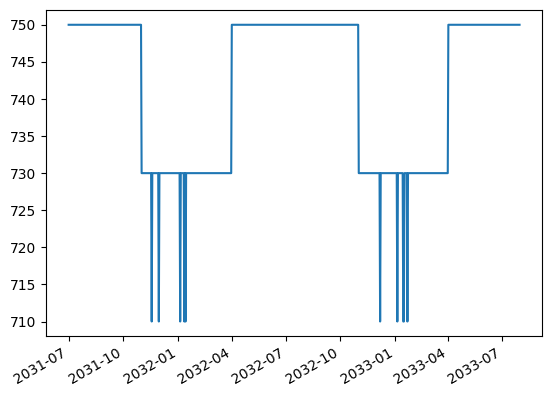

In [25]:
capacity_series = pd.Series(capacity_list, index=snapshots_day_dt)
capacity_series.plot()